# 06 — DiD Analysis v2 (SVM mh_score)

Re-runs the full DiD from notebook 03 using **mh_score** (mean of three SVM classifiers from notebook 05)
instead of VADER distress_score.

**Motivation**: VADER is a general-purpose lexicon that conflates topic salience with distress.
The SVM classifiers (trained on r/anxiety, r/depression, r/stress) capture
domain-specific distress language more sensitively.

**Differences from notebook 03**:
- Loads `user_weekly_scores_v2.parquet` (adds `mean_mh_score`)
- All DiD regressions use `mean_mh_score` as the outcome
- RQ2 model is the same but uses the new outcome
- Event-study and cross-cycle checks replicated on new outcome

**Inputs**: outputs of notebooks 02, 04, 05
**Outputs**: `fig_event_study_v2.png`, `fig_did_results_v2.png`, summary tables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
RAW_DIR  = ROOT / 'data' / 'raw'
FIG_DIR  = ROOT / 'figures'
MODEL_DIR = ROOT / 'models'

# v2 uses SVM-scored weekly scores
user_weekly   = pd.read_parquet(DATA_DIR / 'user_weekly_scores_v2.parquet')
exposure_df   = pd.read_parquet(DATA_DIR / 'exposure_labels.parquet')
breadth_df    = pd.read_parquet(DATA_DIR / 'user_community_breadth.parquet')

print('Loaded v2 data')
print(f'  user_weekly_v2: {len(user_weekly):,} rows')
print(f'  New columns: {[c for c in user_weekly.columns if "mh" in c or "anx" in c or "dep" in c or "str" in c]}')

Loaded v2 data
  user_weekly_v2: 210,133 rows
  New columns: ['mean_distress', 'mean_anx', 'mean_dep', 'mean_str', 'mean_mh_score', 'max_mh_score']


## 1) Build ±2-week panel on mh_score

In [2]:
def week_str_to_dt(w):
    return pd.to_datetime(w + '-1', format='%G-W%V-%u', utc=True)

def dt_to_week_str(dt):
    return dt.strftime('%G-W%V')

uw_lookup = user_weekly.set_index(['author', 'week'])
WINDOW = 2

panel_rows = []
for _, row in exposure_df.iterrows():
    author     = row['author']
    event_week = row['event_week']
    exposed    = row['exposed']
    event_dt   = week_str_to_dt(event_week)

    for offset in range(-WINDOW, WINDOW + 1):
        if offset == 0:
            continue
        target_week = dt_to_week_str(event_dt + timedelta(weeks=offset))
        try:
            m = uw_lookup.loc[(author, target_week)]
            panel_rows.append({
                'author':         author,
                'event_week':     event_week,
                'target_week':    target_week,
                'offset':         offset,
                'post':           int(offset > 0),
                'exposed':        int(exposed),
                'mean_mh_score':  m['mean_mh_score'],   # PRIMARY OUTCOME
                'mean_distress':  m['mean_distress'],   # keep for comparison
                'mean_compound':  m['mean_compound'],
                'n_posts':        m['n_posts'],
            })
        except KeyError:
            pass

panel = pd.DataFrame(panel_rows)
print(f'Panel rows: {len(panel):,}')
print(f'Exposed obs: {(panel["exposed"]==1).sum():,}  |  Unexposed obs: {(panel["exposed"]==0).sum():,}')
print('\nmh_score by exposed × post:')
print(panel.groupby(['exposed','post'])['mean_mh_score'].mean().round(4))

Panel rows: 200,646
Exposed obs: 8,471  |  Unexposed obs: 192,175

mh_score by exposed × post:
exposed  post
0        0       0.4264
         1       0.4292
1        0       0.4430
         1       0.4444
Name: mean_mh_score, dtype: float64


## 2) Propensity Score Matching (on mh_score pre-event)

In [3]:
pre_panel = panel[panel['post'] == 0].groupby(['author', 'event_week', 'exposed']).agg(
    pre_mh_score = ('mean_mh_score', 'mean'),
    pre_distress = ('mean_distress',  'mean'),
    pre_compound = ('mean_compound',  'mean'),
    pre_n_posts  = ('n_posts',        'sum'),
).reset_index().dropna(subset=['pre_mh_score'])

print(f'Pre-panel: {len(pre_panel):,} rows')
print(pre_panel.groupby('exposed')[['pre_mh_score', 'pre_distress', 'pre_n_posts']].mean().round(4))

# Propensity score: match on pre_mh_score + pre_n_posts
features = ['pre_mh_score', 'pre_n_posts']
pre_clean = pre_panel.dropna(subset=features).copy()

scaler = StandardScaler()
X = scaler.fit_transform(pre_clean[features])
y = pre_clean['exposed'].values

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X, y)
pre_clean['pscore'] = lr.predict_proba(X)[:, 1]

print('\nPropensity scores by exposure:')
print(pre_clean.groupby('exposed')['pscore'].describe().round(4))

Pre-panel: 74,018 rows
         pre_mh_score  pre_distress  pre_n_posts
exposed                                         
0              0.4249        0.0466       4.8664
1              0.4420        0.0614       6.6934

Propensity scores by exposure:
           count    mean     std     min     25%     50%     75%     max
exposed                                                                 
0        71174.0  0.0383  0.0130  0.0096  0.0309  0.0371  0.0439  0.8425
1         2844.0  0.0423  0.0189  0.0141  0.0339  0.0405  0.0477  0.7117


In [4]:
CALIPER = 0.05

exposed_df   = pre_clean[pre_clean['exposed'] == 1].reset_index(drop=True)
unexposed_df = pre_clean[pre_clean['exposed'] == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(unexposed_df[['pscore']])
dists, indices = nn.kneighbors(exposed_df[['pscore']])

matched_pairs = []
for i, (dist, idx) in enumerate(zip(dists.flatten(), indices.flatten())):
    if dist <= CALIPER:
        matched_pairs.append({
            'exposed_author':   exposed_df.loc[i, 'author'],
            'exposed_week':     exposed_df.loc[i, 'event_week'],
            'unexposed_author': unexposed_df.loc[idx, 'author'],
            'unexposed_week':   unexposed_df.loc[idx, 'event_week'],
        })

matched = pd.DataFrame(matched_pairs)
print(f'Matched pairs: {len(matched):,} (caliper={CALIPER})')

matched_keys = (
    set(zip(matched['exposed_author'],   matched['exposed_week'])) |
    set(zip(matched['unexposed_author'], matched['unexposed_week']))
)
panel['key'] = list(zip(panel['author'], panel['event_week']))
matched_panel = panel[panel['key'].isin(matched_keys)].copy()

print(f'Matched panel rows: {len(matched_panel):,}')
print(matched_panel.groupby(['exposed','post'])['mean_mh_score'].mean().round(4))

Matched pairs: 2,843 (caliper=0.05)
Matched panel rows: 12,806
exposed  post
0        0       0.4435
         1       0.4344
1        0       0.4430
         1       0.4467
Name: mean_mh_score, dtype: float64


## 3) RQ1 — DiD regression on mh_score

In [5]:
import statsmodels.formula.api as smf

did_data = matched_panel.dropna(subset=['mean_mh_score']).copy()
did_data['post_x_exposed'] = did_data['post'] * did_data['exposed']

# RQ1: mh_score ~ post + exposed + post×exposed + log(n_posts)
model_rq1 = smf.ols(
    'mean_mh_score ~ post + exposed + post_x_exposed + np.log1p(n_posts)',
    data=did_data
).fit(cov_type='HC3')

print('=== RQ1: DiD on mh_score (SVM classifiers) ===')
tbl = model_rq1.summary2().tables[1]
print(tbl.round(4))

coef = model_rq1.params['post_x_exposed']
pval = model_rq1.pvalues['post_x_exposed']
ci   = model_rq1.conf_int().loc['post_x_exposed']

print(f'\nDiD estimate (post×exposed): {coef:.4f}')
print(f'95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'p-value: {pval:.4f}')
print()
if pval < 0.05:
    direction = 'INCREASES' if coef > 0 else 'DECREASES'
    print(f'✓ Significant: exposure {direction} mh_score (p={pval:.4f})')
else:
    print(f'✗ Not significant at p<0.05 (p={pval:.4f})')
    print('  Consider: effect may be real but small relative to noise, or exposure window needs tuning.')

=== RQ1: DiD on mh_score (SVM classifiers) ===
                    Coef.  Std.Err.         z   P>|z|  [0.025  0.975]
Intercept          0.4406    0.0016  279.5937  0.0000  0.4375  0.4437
post              -0.0092    0.0017   -5.4661  0.0000 -0.0124 -0.0059
exposed           -0.0007    0.0014   -0.4659  0.6413 -0.0035  0.0022
post_x_exposed     0.0128    0.0023    5.6257  0.0000  0.0083  0.0172
np.log1p(n_posts)  0.0022    0.0007    3.1944  0.0014  0.0009  0.0036

DiD estimate (post×exposed): 0.0128
95% CI: [0.0083, 0.0172]
p-value: 0.0000

✓ Significant: exposure INCREASES mh_score (p=0.0000)


## 4) RQ2 — Community breadth as moderator

In [6]:
did_data_rq2 = did_data.merge(
    breadth_df[['author', 'community_breadth', 'community_breadth_log']],
    on='author', how='left'
)

n_with = did_data_rq2['community_breadth'].notna().sum()
print(f'Records with breadth data: {n_with:,} / {len(did_data_rq2):,}')

if n_with > 100:
    rq2_data = did_data_rq2.dropna(subset=['community_breadth_log']).copy()

    model_rq2 = smf.ols(
        'mean_mh_score ~ post + exposed + post_x_exposed '
        '+ community_breadth_log '
        '+ post_x_exposed:community_breadth_log '
        '+ np.log1p(n_posts)',
        data=rq2_data
    ).fit(cov_type='HC3')

    print('=== RQ2: DiD × Community Breadth on mh_score ===')
    tbl2 = model_rq2.summary2().tables[1]
    print(tbl2.round(4))

    mod_coef = model_rq2.params.get('post_x_exposed:community_breadth_log', np.nan)
    mod_pval = model_rq2.pvalues.get('post_x_exposed:community_breadth_log', np.nan)
    print(f'\nModeration coefficient (post×exposed×breadth_log): {mod_coef:.4f}')
    print(f'p-value: {mod_pval:.4f}')
    print()
    if mod_pval < 0.05 and mod_coef < 0:
        print('✓ Stress-buffering supported: higher breadth attenuates distress increase')
    elif mod_pval < 0.05 and mod_coef > 0:
        print('✗ Reverse: higher breadth amplifies distress increase')
    else:
        print('✗ Moderation not significant')
else:
    print('community_breadth data not available — run notebook 04 first')

Records with breadth data: 12,764 / 12,806
=== RQ2: DiD × Community Breadth on mh_score ===
                                       Coef.  Std.Err.         z   P>|z|  \
Intercept                             0.4418    0.0021  212.3313  0.0000   
post                                 -0.0092    0.0017   -5.4447  0.0000   
exposed                              -0.0008    0.0015   -0.5196  0.6033   
post_x_exposed                        0.0054    0.0038    1.4087  0.1589   
community_breadth_log                -0.0004    0.0005   -0.7534  0.4512   
post_x_exposed:community_breadth_log  0.0028    0.0011    2.4698  0.0135   
np.log1p(n_posts)                     0.0021    0.0007    3.0509  0.0023   

                                      [0.025  0.975]  
Intercept                             0.4377  0.4459  
post                                 -0.0125 -0.0059  
exposed                              -0.0036  0.0021  
post_x_exposed                       -0.0021  0.0128  
community_breadth_log   

## 5) Event-study plot

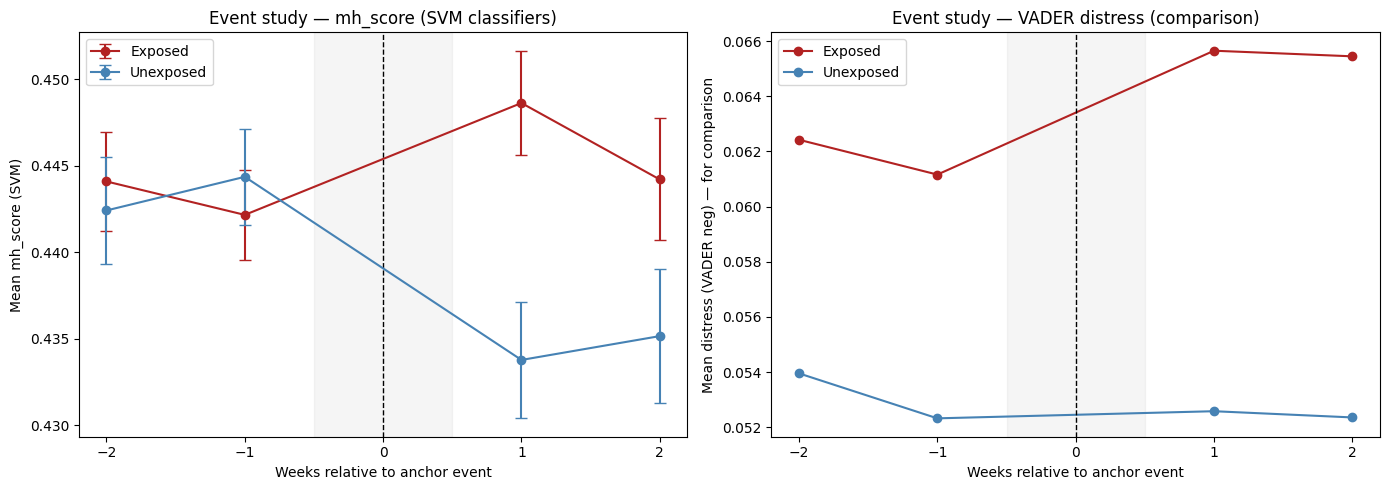

Saved fig_event_study_v2.png


In [7]:
event_study = (
    matched_panel.groupby(['offset', 'exposed'])
    .agg(
        mean_mh  = ('mean_mh_score', 'mean'),
        se_mh    = ('mean_mh_score', lambda x: x.sem()),
        mean_dst = ('mean_distress',  'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exp_val, label, color in [(1, 'Exposed', 'firebrick'), (0, 'Unexposed', 'steelblue')]:
    sub = event_study[event_study['exposed'] == exp_val]
    axes[0].errorbar(
        sub['offset'], sub['mean_mh'],
        yerr=sub['se_mh'] * 1.96,
        label=label, color=color, marker='o', capsize=4
    )
    axes[1].plot(sub['offset'], sub['mean_dst'], label=label, color=color, marker='o')

for ax in axes:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axvspan(-0.5, 0.5, alpha=0.08, color='gray')
    ax.set_xticks(range(-WINDOW, WINDOW+1))
    ax.set_xlabel('Weeks relative to anchor event')
    ax.legend()

axes[0].set_ylabel('Mean mh_score (SVM)')
axes[0].set_title('Event study — mh_score (SVM classifiers)')
axes[1].set_ylabel('Mean distress (VADER neg) — for comparison')
axes[1].set_title('Event study — VADER distress (comparison)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_event_study_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_event_study_v2.png')

## 6) Results comparison: VADER vs. SVM

In [8]:
# Side-by-side comparison table
model_vader = smf.ols(
    'mean_distress ~ post + exposed + post_x_exposed + np.log1p(n_posts)',
    data=did_data
).fit(cov_type='HC3')

print('=== COMPARISON: VADER vs. SVM DiD estimates ===')
print(f'\n{"":<30} {"VADER":>12} {"SVM mh_score":>14}')
print('-' * 60)
for term in ['post', 'exposed', 'post_x_exposed', 'np.log1p(n_posts)']:
    coef_v = model_vader.params.get(term, np.nan)
    pval_v = model_vader.pvalues.get(term, np.nan)
    coef_s = model_rq1.params.get(term, np.nan)
    pval_s = model_rq1.pvalues.get(term, np.nan)
    sig_v  = '***' if pval_v < 0.001 else ('**' if pval_v < 0.01 else ('*' if pval_v < 0.05 else ''))
    sig_s  = '***' if pval_s < 0.001 else ('**' if pval_s < 0.01 else ('*' if pval_s < 0.05 else ''))
    print(f'{term:<30} {coef_v:>8.4f}{sig_v:<3}  {coef_s:>8.4f}{sig_s:<3}')
print('\nSignificance: * p<0.05  ** p<0.01  *** p<0.001')

=== COMPARISON: VADER vs. SVM DiD estimates ===

                                      VADER   SVM mh_score
------------------------------------------------------------
post                            -0.0006      -0.0092***
exposed                          0.0086***   -0.0007   
post_x_exposed                   0.0044       0.0128***
np.log1p(n_posts)                0.0009       0.0022** 

Significance: * p<0.05  ** p<0.01  *** p<0.001


## 7) Cross-cycle replication

In [9]:
def assign_cycle(w):
    dt = pd.to_datetime(w + '-1', format='%G-W%V-%u', utc=True)
    if pd.Timestamp('2023-08-01', tz='UTC') <= dt < pd.Timestamp('2024-08-01', tz='UTC'):
        return '2023-24'
    elif pd.Timestamp('2024-08-01', tz='UTC') <= dt < pd.Timestamp('2025-08-01', tz='UTC'):
        return '2024-25'
    return 'other'

matched_panel['cycle'] = matched_panel['event_week'].apply(assign_cycle)

print('=== Cross-cycle replication: DiD on mh_score ===')
for cycle in ['2023-24', '2024-25']:
    sub = matched_panel[matched_panel['cycle'] == cycle].copy()
    if len(sub) < 100:
        print(f'  {cycle}: insufficient data ({len(sub)} rows)')
        continue
    sub['post_x_exposed'] = sub['post'] * sub['exposed']
    try:
        m = smf.ols(
            'mean_mh_score ~ post + exposed + post_x_exposed + np.log1p(n_posts)',
            data=sub
        ).fit(cov_type='HC3')
        coef = m.params['post_x_exposed']
        pval = m.pvalues['post_x_exposed']
        sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
        print(f'  {cycle}: DiD = {coef:.4f} ({sig}, p={pval:.4f}, n={len(sub):,})')
    except Exception as e:
        print(f'  {cycle}: error — {e}')

=== Cross-cycle replication: DiD on mh_score ===
  2023-24: DiD = 0.0118 (***, p=0.0007, n=5,531)
  2024-25: DiD = 0.0134 (***, p=0.0000, n=7,275)
